# The repeat harness — every number as a distribution

**The prerequisite before `lit-ppf`** (`dataset_plan.md` §Phase 4, order of work, item 5).
`lit-ransac` swings F1 **0,00 → 0,94** on one fixed scene, varying nothing but its RANSAC
seed, so a single-draw number for a randomised method is noise. The advisor's protocol:

> *"Random consensus RANSAC'ın... aynı algoritmayı 100 defa koşsan birebir aynı şeyi elde
> etmeyeceksin... box plot'lar, minimum ve deviation'ı gösterecek şekilde."*

`scripts/baselines/harness.py` provides it: one dataframe over
`method × scene × seed × arm × view × noise_scale`, with three design decisions worth
stating up front.

1. **Each method's L0 is its own paper's coarse stage, not a shared mask.** Conflating the
   stages already produced one wrong conclusion (notebook `05`'s ladder). `ours` gets
   `object_id`; `lit-ransac` gets the ~40 mm truth band (its PointNet++); `lit-regiongrow`
   gets per-surface masks + the derived crop (its FastSAM); `lit-lobb` gets `object_id`
   (its K-Net).
2. **Deterministic methods still run `verify_seeds` times.** *"The deterministic methods
   show zero spread"* is a reportable finding only if the spread was measured.
3. **The noise axis is a multiplier on the derived σ_z** — never a fraction of range. The
   harness scales `subpixel_px` and `lateral_sigma_px` in a copy of the sensor model, so
   "200% noise" means 2× the σ_z the stereo geometry derives.

**Validated before use**: `tests/test_harness.py` pushes a fake oracle — ground truth plus
*known* noise, phantoms, and misses — through the full pipeline and asserts closed-form
expectations. The first version of that test failed, and the failure was in the fake, not
the harness: jittering the stored 0,1 mm-spacing truth gave a prediction whose densified
mass was set by storage density, hiding a phantom at 1% precision cost instead of ~14%.

In [1]:
import sys
sys.path.insert(0, "..")
sys.path.insert(0, "../scripts")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from baselines import balanced_corpus, emd_mm, prepare, run_matrix, spread

CORPUS = balanced_corpus("../out/bench", per_type=50)
print({k: len(v) for k, v in CORPUS.items()})

{'T': 50, 'butt': 50, 'corner': 50, 'edge': 50, 'lap': 50}


## The fake-oracle validation, shown

Known σ in, measured RMSE out. The perpendicular component of isotropic 3-D jitter is
Rayleigh with mean `σ·√(π/2)`, so the recovered error must track the injected one linearly
— and a phantom must cost precision without stealing a match from any real seam.

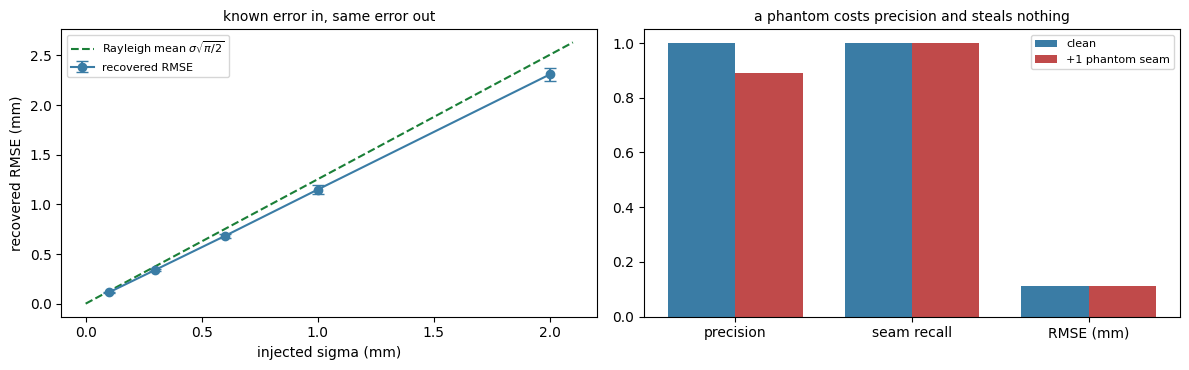

In [2]:
val_prep = prepare(CORPUS["T"][:1] + CORPUS["corner"][:1])
rows = []
for sigma in (0.1, 0.3, 0.6, 1.0, 2.0):
    d = run_matrix(val_prep, methods=["fake-oracle"], seeds=range(4),
                   method_kw={"fake-oracle": {"sigma_mm": sigma}})
    d["sigma_in"] = sigma
    rows.append(d)
val = pd.concat(rows, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
g = val.groupby("sigma_in").rmse_med
axes[0].errorbar(g.mean().index, g.mean().values, yerr=g.std().values, marker="o",
                 c="#3a7ca5", capsize=4, label="recovered RMSE")
s_ = np.linspace(0, 2.1, 50)
axes[0].plot(s_, s_ * np.sqrt(np.pi / 2), "--", c="#1a7f37",
             label=r"Rayleigh mean $\sigma\sqrt{\pi/2}$")
axes[0].set_xlabel("injected sigma (mm)"); axes[0].set_ylabel("recovered RMSE (mm)")
axes[0].legend(fontsize=8)
axes[0].set_title("known error in, same error out", fontsize=10)

ph = run_matrix(val_prep, methods=["fake-oracle"], seeds=range(4),
                method_kw={"fake-oracle": {"sigma_mm": 0.1, "p_phantom": 1.0}})
cl = run_matrix(val_prep, methods=["fake-oracle"], seeds=range(4),
                method_kw={"fake-oracle": {"sigma_mm": 0.1}})
x = np.arange(3)
axes[1].bar(x - 0.19, [cl.precision.mean(), cl.seam_recall.mean(), cl.rmse_med.mean()],
            0.38, label="clean", color="#3a7ca5")
axes[1].bar(x + 0.19, [ph.precision.mean(), ph.seam_recall.mean(), ph.rmse_med.mean()],
            0.38, label="+1 phantom seam", color="#c04a4a")
axes[1].set_xticks(x); axes[1].set_xticklabels(["precision", "seam recall", "RMSE (mm)"])
axes[1].legend(fontsize=8)
axes[1].set_title("a phantom costs precision and steals nothing", fontsize=10)
plt.tight_layout(); plt.show()

## The advisor's figure — `lit-ransac` as box plots

30 seeds per scene, one box per scene, its own coarse stage supplied. Everything a single
number would have hidden is the box: scenes that are a coin flip (min 0, median 0,9),
scenes that fail structurally at every seed (a box collapsed at 0), and scenes that are
genuinely solved (a box collapsed at 1).

  10/16 scenes


480 rows = 16 scenes x 30 seeds


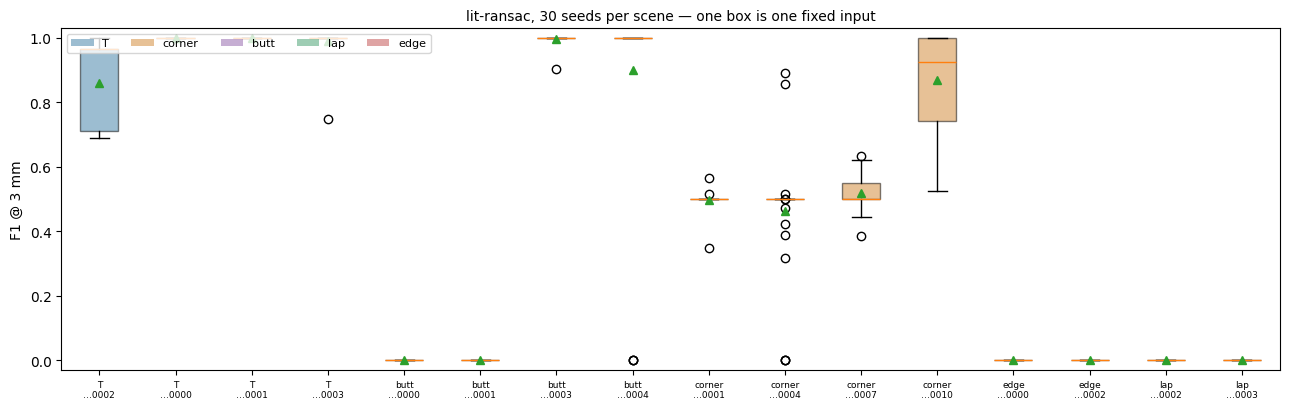

scenes that are a coin flip (spread > 0,5): 2 of 16
scenes failing at EVERY seed (max = 0):     6 of 16 — structural, not sampling


In [3]:
N_SEEDS = 30
box_prep = prepare(CORPUS["T"][:4] + CORPUS["corner"][:4] + CORPUS["butt"][:4]
                   + CORPUS["lap"][:2] + CORPUS["edge"][:2])
ransac = run_matrix(box_prep, methods=["lit-ransac"], seeds=range(N_SEEDS), progress=True)
print(f"{len(ransac)} rows = {ransac.scene_id.nunique()} scenes x {N_SEEDS} seeds")

order = ransac.groupby("scene_id").agg(jt=("joint_type", "first"),
                                       med=("f1", "median")).sort_values(["jt", "med"])
fig, ax = plt.subplots(figsize=(13, 4.2))
data = [ransac[ransac.scene_id == s].f1.values for s in order.index]
colors = {"T": "#3a7ca5", "corner": "#d1842f", "butt": "#8f5fa8",
          "lap": "#3f9c6b", "edge": "#c04a4a"}
bp = ax.boxplot(data, showmeans=True, patch_artist=True)
for patch, jt in zip(bp["boxes"], order.jt):
    patch.set_facecolor(colors[jt]); patch.set_alpha(0.5)
ax.set_xticklabels([f"{jt}\n…{s[-4:]}" for s, jt in order.jt.items()], fontsize=6.5)
ax.set_ylabel("F1 @ 3 mm"); ax.set_ylim(-0.03, 1.03)
handles = [plt.Rectangle((0, 0), 1, 1, fc=c, alpha=0.5) for c in colors.values()]
ax.legend(handles, colors.keys(), fontsize=8, ncol=5, loc="upper left")
ax.set_title(f"lit-ransac, {N_SEEDS} seeds per scene — one box is one fixed input",
             fontsize=10)
plt.tight_layout(); plt.show()

sp = spread(ransac)
print(f"scenes that are a coin flip (spread > 0,5): "
      f"{int((sp.spread > 0.5).sum())} of {len(sp)}")
print(f"scenes failing at EVERY seed (max = 0):     "
      f"{int((sp['max'] == 0).sum())} of {len(sp)} — structural, not sampling")

## The zero-spread finding, measured

The three deterministic methods run `verify_seeds = 3` times each. That the spread comes
back exactly zero is the point: **method reproducibility is a property this generator can
measure and the field does not report.** A reviewer reading a single number from any of
these papers has no way to know which column they are in.

In [4]:
det_prep = prepare(CORPUS["T"][:3] + CORPUS["corner"][:3])
det = run_matrix(det_prep, methods=["ours", "lit-regiongrow", "lit-lobb", "lit-ransac"],
                 seeds=range(8), verify_seeds=3, progress=True)

sp = spread(det).merge(det.groupby("scene_id").joint_type.first(), on="scene_id")
tbl = sp.groupby("method").agg(scenes=("spread", "size"),
                               max_spread=("spread", "max"),
                               runs=("count", "sum"))
print(tbl.round(3).to_string())
print()
for m in ("ours", "lit-regiongrow", "lit-lobb"):
    assert (sp[sp.method == m].spread == 0).all(), m
print("deterministic methods: spread exactly 0 in every scene (asserted, not assumed)")
print("lit-ransac: max spread "
      f"{sp[sp.method == 'lit-ransac'].spread.max():.2f} on the same scenes")

                scenes  max_spread  runs
method                                  
lit-lobb             6       0.000    18
lit-ransac           6       0.574    48
lit-regiongrow       6       0.000    18
ours                 6       0.000    18

deterministic methods: spread exactly 0 in every scene (asserted, not assumed)
lit-ransac: max spread 0.57 on the same scenes


## The noise axis

`noise_scale` multiplies the derived σ_z. 0 = clean, 1 = the scene's stored sensor profile,
2 = twice it. This is the "zero noise / %100 / %200" table axis the meeting asked for, with
the percentage defined against the sensor model rather than against range.

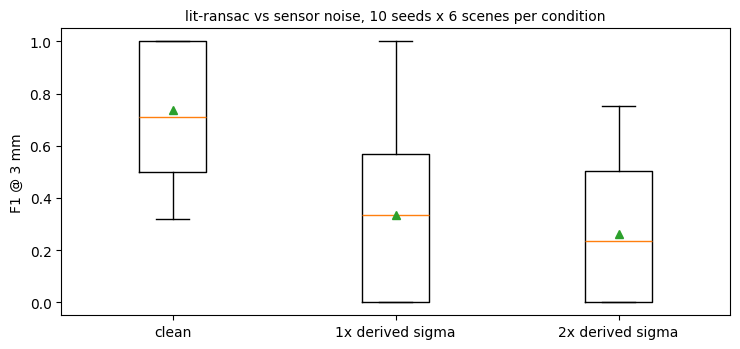

,f1,rmse_med,seam_recall
noise_scale,,,
0.0,0.711,1.712,1.0
1.0,0.334,1.908,1.0
2.0,0.236,2.138,1.0


In [5]:
noise_rows = []
for ns in (0.0, 1.0, 2.0):
    d = run_matrix(det_prep, methods=["lit-ransac"], seeds=range(10), noise_scale=ns)
    noise_rows.append(d)
noise = pd.concat(noise_rows, ignore_index=True)

fig, ax = plt.subplots(figsize=(7.5, 3.6))
data = [noise[noise.noise_scale == ns].f1.values for ns in (0.0, 1.0, 2.0)]
ax.boxplot(data, tick_labels=["clean", "1x derived sigma", "2x derived sigma"],
           showmeans=True)
ax.set_ylabel("F1 @ 3 mm")
ax.set_title("lit-ransac vs sensor noise, 10 seeds x 6 scenes per condition", fontsize=10)
plt.tight_layout(); plt.show()

noise.groupby("noise_scale")[["f1", "rmse_med", "seam_recall"]].median().round(3)

## The secondary metric: transport cost

`emd_mm` — exact assignment on 256-point resamples. Read the three rows against each other,
because each metric forgives a different failure:

- **Point precision forgives the stub entirely** (every stub point is on the seam:
  precision 1,0) — which is how `lit-regiongrow`'s coverage collapse stayed invisible to
  the papers' sampled-point RMSE.
- **Symmetric Chamfer catches the stub** (the truth→prediction direction pays ~L/2) but
  **dilutes split coverage**: two half-seams leaving a 10 mm hole score 0,91 — every truth
  point is near *some* prediction — while EMD pays 3,17 to actually transport mass into
  the hole.
- **EMD is the only one of the three that prices every gap**, because a transport plan must
  move mass where it is missing rather than matching each point independently.

Secondary on purpose: O(n³) makes it a table column, not an inner loop.

In [6]:
gt = [np.array([[0.0, 0, 0], [100.0, 0, 0]])]
cases = {
    "full seam, 0,3 mm off": [np.array([[0.0, 0.3, 0], [100.0, 0.3, 0]])],
    "10% stub, perfectly placed": [np.array([[0.0, 0.0, 0], [10.0, 0.0, 0]])],
    "two half-seams": [np.array([[0.0, 0.3, 0], [45.0, 0.3, 0]]),
                       np.array([[55.0, 0.3, 0], [100.0, 0.3, 0]])],
}
from baselines.metrics import chamfer_mm
rows = []
for name, pred in cases.items():
    rows.append({"case": name, "chamfer_mm": chamfer_mm(
        np.vstack([np.linspace(p[0], p[1], 50) for p in pred]), gt)["chamfer"],
        "emd_mm": emd_mm(pred, gt)})
pd.DataFrame(rows).round(2)

,case,chamfer_mm,emd_mm
0,"full seam, 0,3 mm off",0.91,0.30
1,"10% stub, perfectly placed",40.55,32.27
2,two half-seams,0.91,3.17


## What this unblocks

The order of work is now clear through item 5: harness ✔ (this notebook + its tests),
`ours` adapter ✔, ladder inputs written down ✔ (the harness docstring), `lit-regiongrow` ✔,
`lit-lobb` ✔, `lit-ransac` ✔ + repeat harness ✔. **Next: `lit-ppf`** — which runs through
this harness from its first execution, never outside it. `lit-pcaslice` and `lit-modelreg`
after that.

Open here:

- The box plots above are 16 scenes; the paper figure runs the full balanced corpus
  (50/type) through `run_matrix` in one batch job.
- `lit-ppf` consumes **normals**, which no implemented method does — the L2 rung
  (normals *estimated*, not read from the generator) becomes meaningful there and the
  harness will need an `estimated_normals` switch.
- The EMD column is off by default (O(n³)); turn it on for final tables.